|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>The Naive Loop<h1>|
|<h2>Section:</h2>|<h1>The KV cache<h1>|
|<h2>Lecture:</h2>|<h1><b>The cache in bytes: predict it, measure it, find the 2x<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
# find the repo root. The directory you start from does not matter.
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

/home/venugopalan/vllm-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# What it costs to remember

The cache changes $O(N^2)$ compute into $O(N)$ compute. To do that it keeps
every K and V that it ever computed. That is a bill in bytes, and the next
twenty stages are about that bill.

In [2]:
model = AutoModelForCausalLM.from_pretrained(
          'Qwen/Qwen3-0.6B', dtype=torch.bfloat16).cuda().eval()
cfg = model.config

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 24569.21it/s]

### Predict the cost from the config first

In [3]:
print(f'layers           {cfg.num_hidden_layers}')
print(f'attention heads  {cfg.num_attention_heads}')
print(f'kv heads         {cfg.num_key_value_heads}')
print(f'hidden size      {cfg.hidden_size}')

layers           28
attention heads  16
kv heads         8
hidden size      1024


In [4]:
# 2 for K and V, one entry per layer, per kv head, per element of head_dim
head_dim  = cfg.hidden_size // cfg.num_attention_heads
predicted = 2 * cfg.num_hidden_layers * cfg.num_key_value_heads * head_dim * 2

print(f'head_dim = {cfg.hidden_size} / {cfg.num_attention_heads} = {head_dim}')
print(f'predicted: {predicted/1024:.0f} KB per token')

head_dim = 1024 / 16 = 64
predicted: 56 KB per token


### Now measure it

In [5]:
@torch.inference_mode()
def cache_bytes(L):
  x = torch.randint(0, 1000, (1,L), device='cuda')
  past = model(x, use_cache=True).past_key_values
  return sum(t.numel()*t.element_size()
             for layer in past.layers for t in (layer.keys, layer.values))

measured = cache_bytes(256) / 256
print(f'measured:  {measured/1024:.0f} KB per token')
print(f'predicted: {predicted/1024:.0f} KB per token')
print(f'\nout by {measured/predicted:.0f}x')

measured:  112 KB per token
predicted: 56 KB per token

out by 2x


### Find the mistake

The formula is correct. Its input is not. Do not trust your assumption about
the shape. Look at a real cache entry.

In [6]:
@torch.inference_mode()
def one_layer(L=256):
  x = torch.randint(0, 1000, (1,L), device='cuda')
  return model(x, use_cache=True).past_key_values.layers[0].keys

k = one_layer()
print('keys shape (batch, kv_heads, tokens, head_dim):', tuple(k.shape))
print(f'\nreal head_dim:    {k.shape[-1]}')
print(f'assumed head_dim: {head_dim}')
print(f'\ncfg.head_dim = {getattr(cfg, "head_dim", None)}')

keys shape (batch, kv_heads, tokens, head_dim): (1, 8, 256, 128)

real head_dim:    128
assumed head_dim: 64

cfg.head_dim = 128


`head_dim` is a field of its own. Qwen3 sets it to a value other than
`hidden_size / num_attention_heads`. Many models do this.

Derive `head_dim` instead of reading it, and your capacity plan is wrong by
2x. Production finds that error. A review does not.

In [7]:
head_dim  = cfg.head_dim
predicted = 2 * cfg.num_hidden_layers * cfg.num_key_value_heads * head_dim * 2
print(f'predicted: {predicted/1024:.0f} KB per token')
print(f'measured:  {measured/1024:.0f} KB per token')

predicted: 112 KB per token
measured:  112 KB per token


# The bill

In [8]:
free = torch.cuda.mem_get_info()[0]
print(f'{free/1e9:.1f} GB free on this card right now\n')

for ctx in (512, 2048, 8192, 32768):
  per_seq = ctx * predicted
  print(f'{ctx:>6} tokens: {per_seq/1e6:8.1f} MB per sequence, '
        f'{free/per_seq:6.0f} sequences fit')

10.8 GB free on this card right now

   512 tokens:     58.7 MB per sequence,    184 sequences fit
  2048 tokens:    234.9 MB per sequence,     46 sequences fit
  8192 tokens:    939.5 MB per sequence,     12 sequences fit
 32768 tokens:   3758.1 MB per sequence,      3 sequences fit


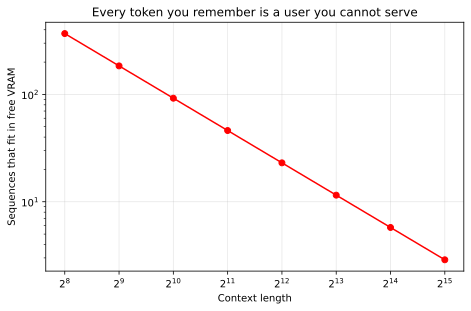

In [9]:
ctxs = np.array([256,512,1024,2048,4096,8192,16384,32768])
fits = free / (ctxs * predicted)

plt.figure(figsize=(7.5,4.5))
plt.plot(ctxs, fits, 'ro-')
plt.xscale('log', base=2); plt.yscale('log')
plt.xlabel('Context length'); plt.ylabel('Sequences that fit in free VRAM')
plt.title('Every token you remember is a user you cannot serve')
plt.grid(alpha=.3); plt.show()

### This plot is the optimistic version

The plot assumes that you allocate exactly what you use. No engine did that
before vLLM.

An engine reserved `max_len` for a sequence the moment it arrived. Your guess
and the real length differ, and the engine wastes the difference.

The vLLM paper measured that waste at **60 to 80 percent** of KV memory.
Divide the red line by four.

Stage 06 makes you build the allocator that recovers the memory. Stage 07
makes attention read through it.

    ./vc guide 6